# A simple example

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from ax.service.ax_client import AxClient, ObjectiveProperties
# from ax.service.utils.instantiation import ObjectiveProperties

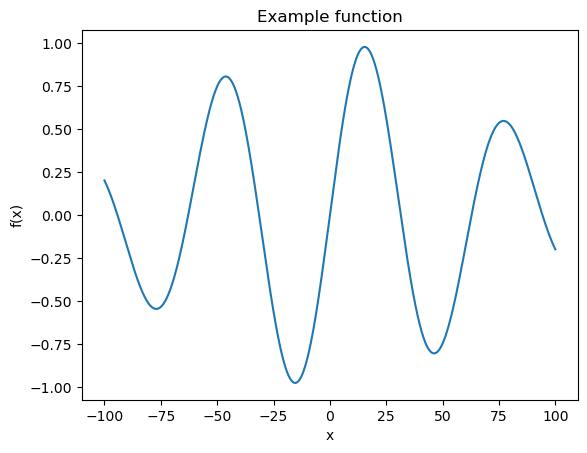

In [2]:
x = np.linspace(-100, 100, 1000)

def f(x):
    return np.sin(x/10)*np.exp(-(x/100)**2)

plt.plot(x, f(x))
plt.title("Example function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

# Let's walk through the anatomy of an Ax statement.


In [3]:
ax_client = AxClient()
ax_client.create_experiment(
    name="basic_demo",
    parameters=[
        {"name": "x", "type": "range", "bounds": [-99., 99.], "value_type": "float"},
    ],
    objectives={"f": ObjectiveProperties(minimize=True)}
)

[INFO 03-27 11:22:05] ax.service.ax_client: Starting optimization with verbose logging. To disable logging, set the `verbose_logging` argument to `False`. Note that float values in the logs are rounded to 6 decimal points.
[INFO 03-27 11:22:05] ax.service.utils.instantiation: Created search space: SearchSpace(parameters=[RangeParameter(name='x', parameter_type=FLOAT, range=[-99.0, 99.0])], parameter_constraints=[]).
[INFO 03-27 11:22:05] ax.modelbridge.dispatch_utils: Using Models.BOTORCH_MODULAR since there is at least one ordered parameter and there are no unordered categorical parameters.
[INFO 03-27 11:22:05] ax.modelbridge.dispatch_utils: Calculating the number of remaining initialization trials based on num_initialization_trials=None max_initialization_trials=None num_tunable_parameters=1 num_trials=None use_batch_trials=False
[INFO 03-27 11:22:05] ax.modelbridge.dispatch_utils: calculated num_initialization_trials=5
[INFO 03-27 11:22:05] ax.modelbridge.dispatch_utils: num_comple

In [4]:
# Define the function to train
def train_evaluate(parameters):
    x = parameters["x"]
    return {"f": f(x)}

In [5]:
# Initialize the array to save results
points = []
values = []

/Users/zdc6/mambaforge/envs/ax/lib/python3.12/site-packages/ax/modelbridge/cross_validation.py:439: UserWarning: Encountered exception in computing model fit quality: RandomModelBridge does not support prediction.
  warn("Encountered exception in computing model fit quality: " + str(e))
[INFO 03-27 11:22:05] ax.service.ax_client: Generated new trial 0 with parameters {'x': 61.193864} using model Sobol.
[INFO 03-27 11:22:05] ax.service.ax_client: Completed trial 0 with data: {'f': (-0.112134, None)}.


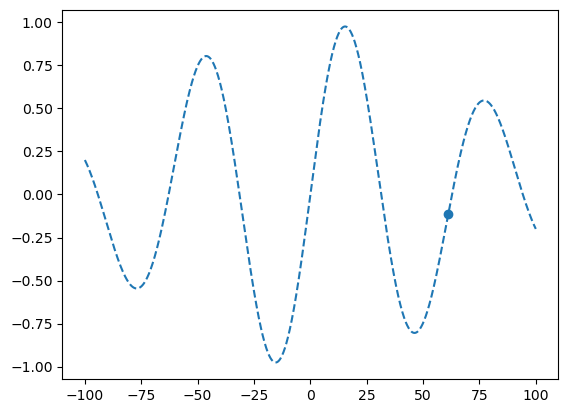

In [6]:
# Generate the parameters and the trial
parameters, trial_index = ax_client.get_next_trial()

# Save the point
points.append(parameters["x"])

# Evaluate the point
result = train_evaluate(parameters)
values.append(result["f"])

# Complete the trial
ax_client.complete_trial(trial_index=trial_index, raw_data=result)

# Plot the result
if len(points) > 1:
    plt.scatter(points[:-1], values[:-1], label="Points explored")
plt.plot(x, f(x), '--', label="actual function")
plt.scatter([points[-1]], [values[-1]], label="Current point")
plt.show()

In [7]:
best_parameters, best_value = ax_client.get_best_parameters()

print(f"So far, the best parameter found is at {best_parameters['x']:.2f} with value {best_value[0]['f']:.2f}.")

So far, the best parameter found is at 61.19 with value -0.11.


In [8]:
for i in range(25):

    parameters, trial_index = ax_client.get_next_trial()

    points.append(parameters["x"])

    result = train_evaluate(parameters)
    values.append(result["f"])
    ax_client.complete_trial(trial_index=trial_index, raw_data=result)

/Users/zdc6/mambaforge/envs/ax/lib/python3.12/site-packages/ax/modelbridge/cross_validation.py:439: UserWarning: Encountered exception in computing model fit quality: RandomModelBridge does not support prediction.
  warn("Encountered exception in computing model fit quality: " + str(e))
[INFO 03-27 11:22:05] ax.service.ax_client: Generated new trial 1 with parameters {'x': -91.342938} using model Sobol.
[INFO 03-27 11:22:05] ax.service.ax_client: Completed trial 1 with data: {'f': (-0.124349, None)}.
/Users/zdc6/mambaforge/envs/ax/lib/python3.12/site-packages/ax/modelbridge/cross_validation.py:439: UserWarning: Encountered exception in computing model fit quality: RandomModelBridge does not support prediction.
  warn("Encountered exception in computing model fit quality: " + str(e))
[INFO 03-27 11:22:05] ax.service.ax_client: Generated new trial 2 with parameters {'x': -37.476419} using model Sobol.
[INFO 03-27 11:22:05] ax.service.ax_client: Completed trial 2 with data: {'f': (0.49498

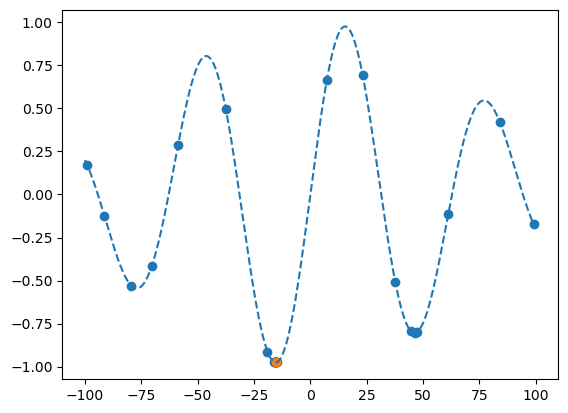

In [9]:
# Plot the result
if len(points) > 1:
    plt.scatter(points[:-1], values[:-1], label="Points explored")
plt.plot(x, f(x), '--', label="actual function")
plt.scatter([points[-1]], [values[-1]], label="Current point")
plt.show()

In [10]:
ax_client.get_trials_data_frame()

,trial_index,arm_name,trial_status,generation_method,generation_node,f,x
0,0,0_0,COMPLETED,Sobol,GenerationStep_0,-0.112134,61.193864
1,1,1_0,COMPLETED,Sobol,GenerationStep_0,-0.124349,-91.342938
2,2,2_0,COMPLETED,Sobol,GenerationStep_0,0.494986,-37.476419
3,3,3_0,COMPLETED,Sobol,GenerationStep_0,0.664003,7.309266
4,4,4_0,COMPLETED,Sobol,GenerationStep_0,-0.508120,37.672123
5,5,5_0,COMPLETED,BoTorch,GenerationStep_1,-0.795316,44.729526
6,6,6_0,COMPLETED,BoTorch,GenerationStep_1,-0.797900,47.457050
7,7,7_0,COMPLETED,BoTorch,GenerationStep_1,-0.416906,-70.364324
8,8,8_0,COMPLETED,BoTorch,GenerationStep_1,-0.171701,99.000000
9,9,9_0,COMPLETED,BoTorch,GenerationStep_1,0.284712,-58.696799


In [13]:
ax_client.save_to_json_file("experiment_results.json")

[INFO 03-27 11:40:00] ax.service.ax_client: Saved JSON-serialized state of optimization to `experiment_results.json`.


In [11]:
best_parameters, best_value = ax_client.get_best_parameters()

print(f"So far, the best parameter found is at {best_parameters['x']:.2f} with value {best_value[0]['f']:.2f}.")

So far, the best parameter found is at -15.40 with value -0.98.


Now, we can take our best parameters and fit our model!